# Assignment 5: Food Delivery Time Prediction

## Objective
Predict whether delivery is **Fast (0)** or **Delayed (1)** and explore delivery patterns using clustering.

This notebook includes:
1. Data preprocessing and feature engineering
2. K-Means and Hierarchical clustering
3. Neural network classification (with baseline comparison)
4. Reporting-ready visualizations and insights


In [1]:
import warnings
warnings.filterwarnings('ignore')

import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

sns.set(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)


In [2]:
# Update if needed
DATA_PATH = 'Food_Delivery_Time_Prediction.csv'

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
display(df.head())

print('\nMissing values:')
display(df.isnull().sum().to_frame('missing_count'))


Shape: (200, 15)


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34



Missing values:


,missing_count
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


## Phase 1: Data Preprocessing and Feature Engineering


In [3]:
work_df = df.copy()

# Parse location tuples and compute Haversine distance

def parse_lat_lon(value):
    try:
        lat, lon = ast.literal_eval(str(value))
        return float(lat), float(lon)
    except Exception:
        return np.nan, np.nan


def haversine_km(lat1, lon1, lat2, lon2):
    if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
        return np.nan

    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

if 'Customer_Location' in work_df.columns:
    work_df[['customer_lat', 'customer_lon']] = work_df['Customer_Location'].apply(lambda x: pd.Series(parse_lat_lon(x)))

if 'Restaurant_Location' in work_df.columns:
    work_df[['restaurant_lat', 'restaurant_lon']] = work_df['Restaurant_Location'].apply(lambda x: pd.Series(parse_lat_lon(x)))

if set(['customer_lat', 'customer_lon', 'restaurant_lat', 'restaurant_lon']).issubset(work_df.columns):
    work_df['Haversine_Distance_km'] = work_df.apply(
        lambda r: haversine_km(r['customer_lat'], r['customer_lon'], r['restaurant_lat'], r['restaurant_lon']), axis=1
    )

# Rush-hour feature from Order_Time
rush_values = {'Morning', 'Evening'}
if 'Order_Time' in work_df.columns:
    work_df['Rush_Hour'] = work_df['Order_Time'].apply(lambda x: 1 if str(x) in rush_values else 0)

# Binary classification target from Delivery_Time median
if 'Delivery_Time' not in work_df.columns:
    raise ValueError('Delivery_Time column is required.')

threshold = work_df['Delivery_Time'].median()
work_df['Delivery_Status'] = (work_df['Delivery_Time'] > threshold).astype(int)

print(f'Delivery delay threshold (median): {threshold:.2f}')
print('Class counts (0=Fast,1=Delayed):')
display(work_df['Delivery_Status'].value_counts().to_frame('count'))

display(work_df.head())


Delivery delay threshold (median): 72.78
Class counts (0=Fast,1=Delayed):


,count
Delivery_Status,
0,100
1,100


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,customer_lat,customer_lon,restaurant_lat,restaurant_lon,Haversine_Distance_km,Rush_Hour,Delivery_Status
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54,17.030479,79.743077,12.358515,85.100083,775.651198,0,0
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02,15.398319,86.639122,14.174874,77.025606,1042.385597,0,0
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17,15.687342,83.888808,19.594748,82.048482,476.220706,0,0
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23,20.415599,78.046984,16.915906,78.278698,389.912629,1,1
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34,14.786904,78.706532,15.206038,86.203182,806.505886,0,0


In [4]:
# Features for clustering (unsupervised)
cluster_df = work_df.copy()

# Remove IDs/raw tuple strings and target/leakage for clustering view
drop_cols_clustering = [c for c in ['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Delivery_Status'] if c in cluster_df.columns]
cluster_df = cluster_df.drop(columns=drop_cols_clustering)

num_cols_cluster = cluster_df.select_dtypes(exclude=['object']).columns.tolist()
cat_cols_cluster = cluster_df.select_dtypes(include=['object']).columns.tolist()

cluster_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_cluster),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_cluster)
    ]
)

X_cluster = cluster_preprocessor.fit_transform(cluster_df)
print('Clustering matrix shape:', X_cluster.shape)


Clustering matrix shape: (200, 30)


## Phase 2: Clustering
### 2.1 K-Means Clustering


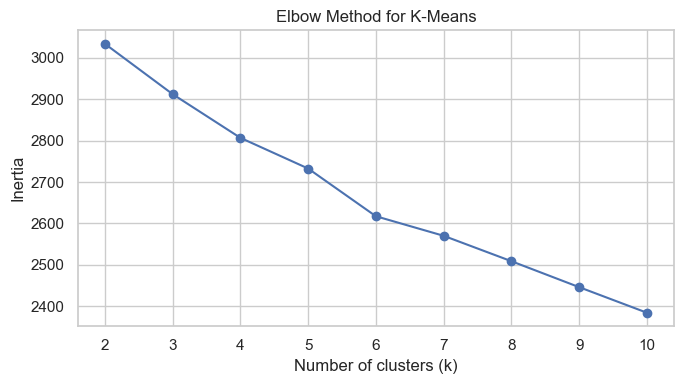

KMeans_Cluster
0    92
1    61
2    47
Name: count, dtype: int64


In [5]:
# Elbow method
inertias = []
k_values = list(range(2, 11))

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# Choose k (you can adjust after viewing elbow)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels_kmeans = kmeans.fit_predict(X_cluster)

work_df['KMeans_Cluster'] = cluster_labels_kmeans
print(work_df['KMeans_Cluster'].value_counts().sort_index())


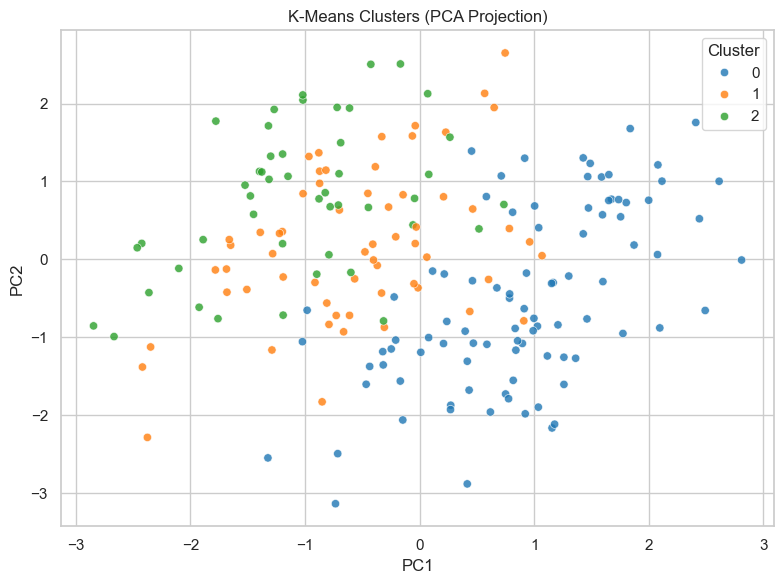

,Avg_Delivery_Time,Delayed_Rate,Avg_Distance
KMeans_Cluster,,,
0,69.470217,0.467391,12.452717
1,64.436066,0.426230,12.875574
2,80.364468,0.659574,7.841489


In [6]:
# 2D visualization using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels_kmeans,
    'Delivery_Status': work_df['Delivery_Status'].values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.8)
plt.title('K-Means Clusters (PCA Projection)')
plt.tight_layout()
plt.show()

# Cluster-wise delivery behavior
cluster_summary = work_df.groupby('KMeans_Cluster').agg(
    Avg_Delivery_Time=('Delivery_Time', 'mean'),
    Delayed_Rate=('Delivery_Status', 'mean'),
    Avg_Distance=('Distance', 'mean')
)
display(cluster_summary)


### 2.2 Hierarchical Clustering


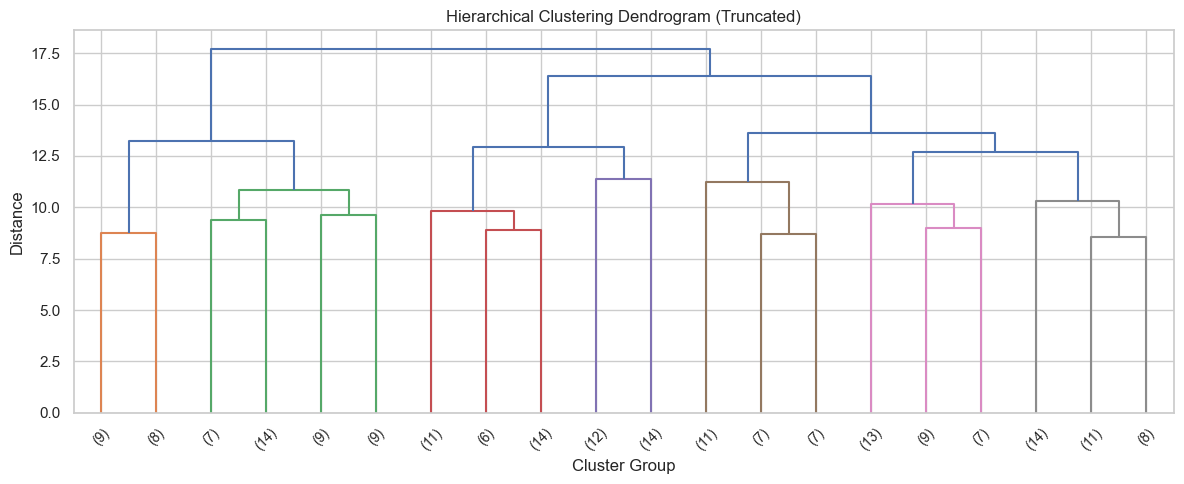

Agglomerative_Cluster
0    87
1    56
2    57
Name: count, dtype: int64
Cluster overlap (KMeans vs Agglomerative):


Agglomerative_Cluster,0,1,2
KMeans_Cluster,,,
0,8,41,43
1,48,8,5
2,31,7,9


In [7]:
# Dendrogram on a sample to keep rendering manageable
try:
    from scipy.cluster.hierarchy import linkage, dendrogram

    sample_size = min(300, X_cluster.shape[0])
    rng = np.random.default_rng(42)
    idx = rng.choice(X_cluster.shape[0], size=sample_size, replace=False)
    X_sample = X_cluster[idx].toarray() if hasattr(X_cluster, 'toarray') else X_cluster[idx]

    Z = linkage(X_sample, method='ward')

    plt.figure(figsize=(12, 5))
    dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=10)
    plt.title('Hierarchical Clustering Dendrogram (Truncated)')
    plt.xlabel('Cluster Group')
    plt.ylabel('Distance')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Dendrogram not shown. Ensure scipy is installed. Error:', e)

# Agglomerative clustering
agg_k = 3
agg = AgglomerativeClustering(n_clusters=agg_k, metric='euclidean', linkage='ward')
cluster_labels_agg = agg.fit_predict(X_cluster.toarray() if hasattr(X_cluster, 'toarray') else X_cluster)

work_df['Agglomerative_Cluster'] = cluster_labels_agg
print(work_df['Agglomerative_Cluster'].value_counts().sort_index())

# Compare KMeans and Agglomerative clusters
comparison = pd.crosstab(work_df['KMeans_Cluster'], work_df['Agglomerative_Cluster'])
print('Cluster overlap (KMeans vs Agglomerative):')
display(comparison)


## Phase 3: Neural Networks for Prediction


In [8]:
# Supervised dataset prep
sup_df = work_df.copy()

drop_cols_supervised = [c for c in ['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Delivery_Time'] if c in sup_df.columns]
sup_df = sup_df.drop(columns=drop_cols_supervised)

y = sup_df['Delivery_Status']
X = sup_df.drop(columns=['Delivery_Status'])

num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

supervised_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = supervised_preprocessor.fit_transform(X_train_raw)
X_test = supervised_preprocessor.transform(X_test_raw)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


Train shape: (160, 31) Test shape: (40, 31)


In [9]:
def evaluate_binary_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f'\n{name} Classification Report:')
    print(classification_report(y_true, y_pred, target_names=['Fast (0)', 'Delayed (1)'], zero_division=0))

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Confusion_Matrix': cm
    }


In [10]:
# Baseline: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
result_lr = evaluate_binary_model('Logistic Regression (Baseline)', y_test, y_pred_lr)

# Neural Network: TensorFlow/Keras if available, else sklearn MLP fallback
result_nn = None

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.optimizers import Adam

    # convert sparse matrix to dense for Keras
    X_train_nn = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
    X_test_nn = X_test.toarray() if hasattr(X_test, 'toarray') else X_test

    tf.random.set_seed(42)

    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

    history = model.fit(
        X_train_nn, y_train,
        validation_split=0.2,
        epochs=40,
        batch_size=32,
        verbose=0
    )

    y_prob_nn = model.predict(X_test_nn, verbose=0).ravel()
    y_pred_nn = (y_prob_nn >= 0.5).astype(int)

    result_nn = evaluate_binary_model('Neural Network (Keras)', y_test, y_pred_nn)

    # Plot training history
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('NN Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title('NN Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print('TensorFlow/Keras unavailable, using sklearn MLPClassifier fallback. Error:', e)
    from sklearn.neural_network import MLPClassifier

    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', learning_rate_init=0.001,
                        max_iter=300, random_state=42)
    mlp.fit(X_train, y_train)
    y_pred_mlp = mlp.predict(X_test)
    result_nn = evaluate_binary_model('Neural Network (MLP Fallback)', y_test, y_pred_mlp)



Logistic Regression (Baseline) Classification Report:
              precision    recall  f1-score   support

    Fast (0)       0.56      0.45      0.50        20
 Delayed (1)       0.54      0.65      0.59        20

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55        40

TensorFlow/Keras unavailable, using sklearn MLPClassifier fallback. Error: No module named 'tensorflow'

Neural Network (MLP Fallback) Classification Report:
              precision    recall  f1-score   support

    Fast (0)       0.55      0.55      0.55        20
 Delayed (1)       0.55      0.55      0.55        20

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55        40



## Phase 4: Reporting and Insights


In [11]:
results = [result_lr, result_nn]

metrics_df = pd.DataFrame([{
    'Model': r['Model'],
    'Accuracy': r['Accuracy'],
    'Precision': r['Precision'],
    'Recall': r['Recall'],
    'F1-Score': r['F1-Score']
} for r in results if r is not None]).sort_values(by='F1-Score', ascending=False)

display(metrics_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}'
}))


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (Baseline),0.5500,0.5417,0.6500,0.5909
1,Neural Network (MLP Fallback),0.5500,0.5500,0.5500,0.5500


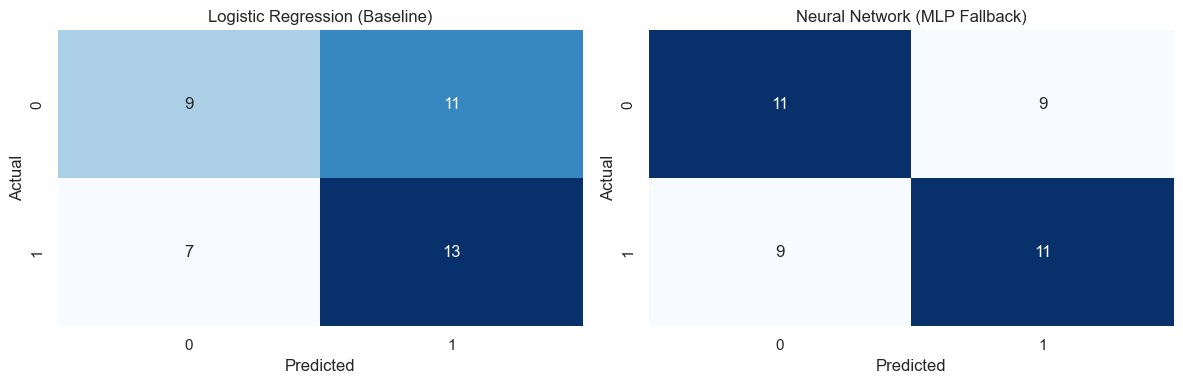

In [12]:
# Confusion matrices for supervised models
valid_results = [r for r in results if r is not None]
fig, axes = plt.subplots(1, len(valid_results), figsize=(6 * len(valid_results), 4))
if len(valid_results) == 1:
    axes = [axes]

for ax, r in zip(axes, valid_results):
    sns.heatmap(r['Confusion_Matrix'], annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(r['Model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()
